# Framing Effects in Risk Communication

Part 0 introduced framing as a cognitive bias at a surface level: "97% of attacks
blocked" versus "3% of attacks got through." Same data, different feeling. That
was the teaser.

This notebook goes deeper. Framing is not just a curiosity — it is a weapon. The
way security data is presented determines which projects get funded, which risks
get ignored, and which teams get blamed. Every board deck, risk register, and
vulnerability report is a framing exercise, whether the author knows it or not.

We cover five mechanisms through which framing manipulates security decisions:

1. **Loss vs gain framing** — prospect theory applied to security investment decisions
2. **Denominator neglect** — how vulnerability counts mislead without rates and context
3. **Risk matrix distortion** — identical scores hiding radically different loss distributions
4. **Anchoring in budget presentations** — how the reference point determines the outcome
5. **Constructive risk communication** — choosing the frame deliberately

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import simulate_aggregate_losses, make_lognormal_severity, var_es

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. Loss Frame vs Gain Frame

Kahneman and Tversky's prospect theory predicts that people are **risk-averse in
the domain of gains** and **risk-seeking in the domain of losses**. The security
investment decision is the same either way:

- **Gain frame:** "Deploying EDR will prevent \$2.4M in expected losses."
- **Loss frame:** "Without EDR, we face \$2.4M in expected losses."

Under the gain frame, the investment feels like locking in a sure gain —
decision-makers approve it because they are risk-averse for gains. Under the
loss frame, the situation feels like an existing gamble — decision-makers become
risk-seeking and are more willing to gamble on avoiding the loss without
spending, so fewer approve.

We simulate 200 decision-makers responding to each frame.

In [2]:
n_respondents = 200

# Gain frame: ~60% approval (risk-averse — lock in the sure gain)
gain_approval_rate = 0.60
gain_responses = sample("binomial", n_respondents, rng=rng, n=1, p=gain_approval_rate)

# Loss frame: ~45% approval (risk-seeking — gamble on avoiding loss)
loss_approval_rate = 0.45
loss_responses = sample("binomial", n_respondents, rng=rng, n=1, p=loss_approval_rate)

# Observed rates and standard errors
gain_obs = gain_responses.mean()
loss_obs = loss_responses.mean()
gain_se = np.sqrt(gain_obs * (1 - gain_obs) / n_respondents)
loss_se = np.sqrt(loss_obs * (1 - loss_obs) / n_respondents)

print(f"Gain frame approval: {gain_obs:.1%} (SE: {gain_se:.1%})")
print(f"Loss frame approval: {loss_obs:.1%} (SE: {loss_se:.1%})")
print(f"Difference: {gain_obs - loss_obs:.1%}")

Gain frame approval: 61.5% (SE: 3.4%)
Loss frame approval: 46.0% (SE: 3.5%)
Difference: 15.5%


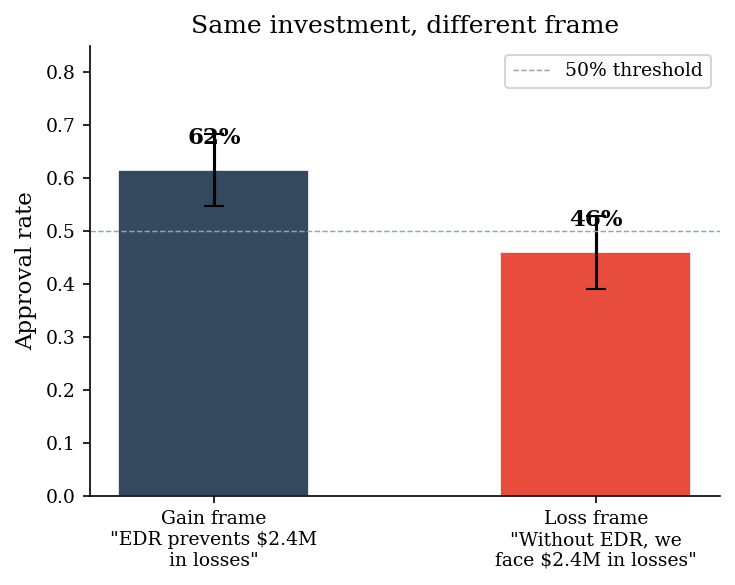

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["Gain frame\n\"EDR prevents $2.4M\nin losses\"", "Loss frame\n\"Without EDR, we\nface $2.4M in losses\""]
rates = [gain_obs, loss_obs]
errors = [1.96 * gain_se, 1.96 * loss_se]
colors = [DARK_BG, ACCENT]

bars = ax.bar(labels, rates, yerr=errors, capsize=5, color=colors,
              edgecolor="white", linewidth=0.8, width=0.5)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
            f"{rate:.0%}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Approval rate")
ax.set_title("Same investment, different frame")
ax.set_ylim(0, 0.85)
ax.axhline(0.5, color=LIGHT_GRAY, linestyle="--", linewidth=0.7, label="50% threshold")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

The expected value of the investment is identical in both framings. No new
information was added. Yet the gain frame produces substantially higher approval.
A CISO who frames investments as "savings" rather than "costs avoided" will
systematically get more projects funded. This is prospect theory in action.

## 2. Denominator Neglect in Vulnerability Reporting

"We have 10,000 critical vulnerabilities" is a statement designed to produce
panic. It works because people evaluate the numerator (10,000 — big number!)
without considering the denominator (out of how many assets? what fraction
matters?).

This is denominator neglect, and vulnerability management is its natural habitat.
We generate a realistic vulnerability landscape and show how four different
presentations of the same data tell four different stories.

In [4]:
# Synthetic vulnerability landscape
total_assets = 50_000
total_vuln_instances = 3_300_000  # scanner output
critical_vulns = 85_000          # CVSS >= 9.0
critical_network_exposed = 22_000  # critical + reachable from network
critical_exposed_unpatched = 10_000  # the actually actionable set

# Risk-adjusted: weight by exploitability (EPSS > 0.1) and exposure
# Only ~30% of critical+exposed+unpatched have high exploitability
risk_adjusted = 3_000

# Industry benchmark: peer median is 0.08% of assets with risk-adjusted criticals
industry_benchmark_rate = 0.08  # percent
our_rate = (risk_adjusted / total_assets) * 100  # percent

presentations = {
    "Raw count\n(scanner output)": critical_exposed_unpatched,
    "Rate per asset\n(critical+exposed+unpatched / assets)": critical_exposed_unpatched / total_assets,
    "Risk-adjusted\n(exploitable + exposed)": risk_adjusted,
    "vs. industry benchmark\n(our rate / peer median)": our_rate / industry_benchmark_rate,
}

print("Four views of the same vulnerability data:\n")
print(f"  Raw count:            {critical_exposed_unpatched:,} critical vulns")
print(f"  Rate per asset:       {critical_exposed_unpatched / total_assets:.1%} of assets affected")
print(f"  Risk-adjusted count:  {risk_adjusted:,} (exploitable + exposed)")
print(f"  Industry comparison:  {our_rate / industry_benchmark_rate:.1f}x peer median")

Four views of the same vulnerability data:

  Raw count:            10,000 critical vulns
  Rate per asset:       20.0% of assets affected
  Risk-adjusted count:  3,000 (exploitable + exposed)
  Industry comparison:  75.0x peer median


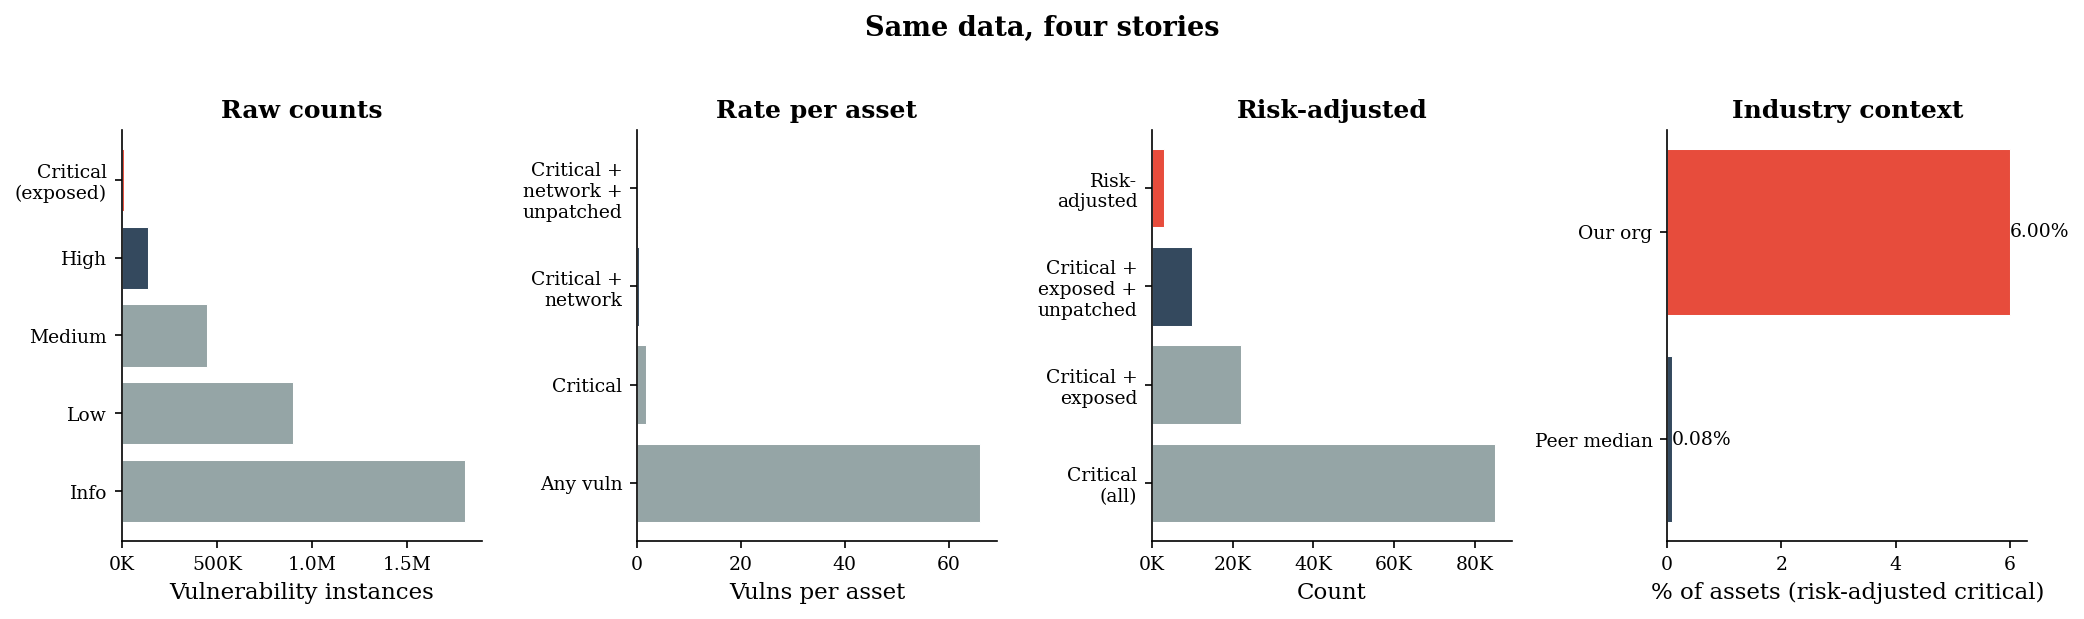

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

# Panel 1: Raw count
ax = axes[0]
categories = ["Info", "Low", "Medium", "High", "Critical\n(exposed)"]
counts = [1_800_000, 900_000, 450_000, 140_000, critical_exposed_unpatched]
colors_p1 = [LIGHT_GRAY, LIGHT_GRAY, LIGHT_GRAY, DARK_BG, ACCENT]
ax.barh(categories, counts, color=colors_p1, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Vulnerability instances")
ax.set_title("Raw counts", fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))

# Panel 2: Rate per asset
ax = axes[1]
rate_categories = ["Any vuln", "Critical", "Critical +\nnetwork", "Critical +\nnetwork +\nunpatched"]
rate_values = [
    total_vuln_instances / total_assets,
    critical_vulns / total_assets,
    critical_network_exposed / total_assets,
    critical_exposed_unpatched / total_assets,
]
colors_p2 = [LIGHT_GRAY, LIGHT_GRAY, DARK_BG, ACCENT]
ax.barh(rate_categories, rate_values, color=colors_p2, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Vulns per asset")
ax.set_title("Rate per asset", fontweight="bold")

# Panel 3: Risk-adjusted
ax = axes[2]
adj_categories = ["Critical\n(all)", "Critical +\nexposed", "Critical +\nexposed +\nunpatched", "Risk-\nadjusted"]
adj_values = [critical_vulns, critical_network_exposed, critical_exposed_unpatched, risk_adjusted]
colors_p3 = [LIGHT_GRAY, LIGHT_GRAY, DARK_BG, ACCENT]
ax.barh(adj_categories, adj_values, color=colors_p3, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Count")
ax.set_title("Risk-adjusted", fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Panel 4: Industry benchmark
ax = axes[3]
bench_categories = ["Peer median", "Our org"]
bench_values = [industry_benchmark_rate, our_rate]
colors_p4 = [DARK_BG, ACCENT]
bars = ax.barh(bench_categories, bench_values, color=colors_p4, edgecolor="white", linewidth=0.5)
ax.set_xlabel("% of assets (risk-adjusted critical)")
ax.set_title("Industry context", fontweight="bold")
for bar, val in zip(bars, bench_values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", fontsize=9)

fig.suptitle("Same data, four stories", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The raw count screams "10,000 critical vulnerabilities" — a number that
triggers alarm in any board meeting. The rate says "20% of assets." The
risk-adjusted count says "3,000 that actually matter." The industry comparison
says "we are 75x worse than our peers." Each is factually correct. Each tells a
different story. The person who chooses the denominator chooses the narrative.

## 3. The Risk Register Framing Problem

The classic 5x5 risk matrix assigns a score by multiplying likelihood and impact
ratings. This imposes a false equivalence: Risk A (likelihood=2, impact=4,
score=8) and Risk B (likelihood=4, impact=2, score=8) receive the same score.
They sit in the same cell on a heat map. They get the same priority.

But their loss distributions are completely different. Risk A is a low-frequency,
high-severity event — it rarely happens, but when it does, the damage is large
and unpredictable. Risk B is a high-frequency, low-severity event — it happens
often but the losses are bounded and predictable.

We simulate both to see what the "same score" actually hides.

In [6]:
n_sim = 10_000

# Risk A: low-frequency, high-severity (likelihood=2, impact=4)
# ~0.5 events/year, severity ~ lognormal with mean ~$1.2M, high variance
sev_a = make_lognormal_severity(meanlog=13.5, sdlog=1.8)
losses_a = simulate_aggregate_losses(n_sim, lam=0.5, severity_sampler=sev_a, rng=make_rng(42))

# Risk B: high-frequency, low-severity (likelihood=4, impact=2)
# ~5 events/year, severity ~ lognormal with mean ~$25K, low variance
sev_b = make_lognormal_severity(meanlog=10.1, sdlog=0.5)
losses_b = simulate_aggregate_losses(n_sim, lam=5.0, severity_sampler=sev_b, rng=make_rng(43))

var_a, es_a = var_es(losses_a, alpha=0.95)
var_b, es_b = var_es(losses_b, alpha=0.95)

print("Both risks score 8 on a 5x5 matrix.\n")
print(f"Risk A (low-freq, high-sev):  Mean = ${np.mean(losses_a):,.0f}  |  VaR95 = ${var_a:,.0f}  |  ES95 = ${es_a:,.0f}")
print(f"Risk B (high-freq, low-sev):  Mean = ${np.mean(losses_b):,.0f}  |  VaR95 = ${var_b:,.0f}  |  ES95 = ${es_b:,.0f}")
print(f"\nTail ratio (ES_A / ES_B):     {es_a / es_b:.1f}x")

Both risks score 8 on a 5x5 matrix.

Risk A (low-freq, high-sev):  Mean = $1,815,601  |  VaR95 = $7,520,839  |  ES95 = $25,958,335
Risk B (high-freq, low-sev):  Mean = $137,554  |  VaR95 = $263,179  |  ES95 = $303,964

Tail ratio (ES_A / ES_B):     85.4x


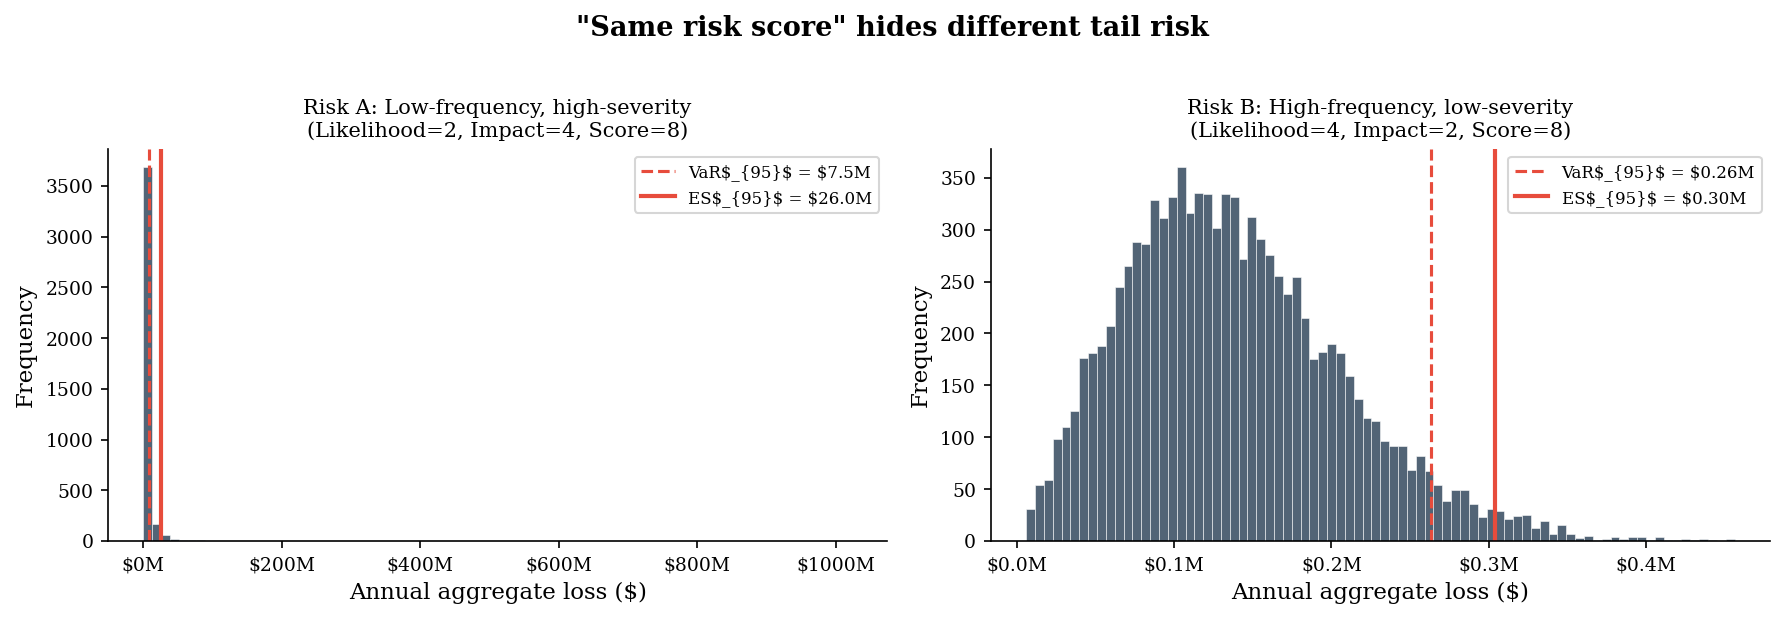

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

# Risk A distribution
ax = axes[0]
nonzero_a = losses_a[losses_a > 0]
ax.hist(nonzero_a, bins=80, color=DARK_BG, edgecolor="white", linewidth=0.3, alpha=0.85)
ax.axvline(var_a, color=ACCENT, linestyle="--", linewidth=1.5, label=f"VaR$_{{95}}$ = ${var_a/1e6:.1f}M")
ax.axvline(es_a, color=ACCENT, linestyle="-", linewidth=2, label=f"ES$_{{95}}$ = ${es_a/1e6:.1f}M")
ax.set_xlabel("Annual aggregate loss ($)")
ax.set_ylabel("Frequency")
ax.set_title("Risk A: Low-frequency, high-severity\n(Likelihood=2, Impact=4, Score=8)", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M"))
ax.legend(loc="upper right", fontsize=8)

# Risk B distribution
ax = axes[1]
nonzero_b = losses_b[losses_b > 0]
ax.hist(nonzero_b, bins=80, color=DARK_BG, edgecolor="white", linewidth=0.3, alpha=0.85)
ax.axvline(var_b, color=ACCENT, linestyle="--", linewidth=1.5, label=f"VaR$_{{95}}$ = ${var_b/1e6:.2f}M")
ax.axvline(es_b, color=ACCENT, linestyle="-", linewidth=2, label=f"ES$_{{95}}$ = ${es_b/1e6:.2f}M")
ax.set_xlabel("Annual aggregate loss ($)")
ax.set_ylabel("Frequency")
ax.set_title("Risk B: High-frequency, low-severity\n(Likelihood=4, Impact=2, Score=8)", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(loc="upper right", fontsize=8)

fig.suptitle("\"Same risk score\" hides different tail risk", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

The risk matrix says these two risks are equivalent. The loss distributions say
otherwise. Risk A has a fat right tail — the 95th percentile loss is multiples
of Risk B's. A risk manager who treats them identically because the matrix says
so is being framed by the tool. The matrix is the frame.

## 4. Anchoring in Board Presentations

A CISO wants an $800K security budget. How it lands depends entirely on the
anchor — the first number the board hears.

- **Strategy 1:** Open with the average breach cost ($4.5M), then present the
  $800K ask. The budget looks like a bargain — 18% of the expected loss.
- **Strategy 2:** Open with last year's budget ($500K), then present the $800K
  ask. The budget looks like a 60% increase.

The request is identical. The anchor determines whether the board perceives
it as a bargain or an overreach.

In [8]:
budget_ask = 800_000

# Anchoring context
anchor_breach = 4_500_000   # average breach cost (Strategy 1 anchor)
anchor_last_year = 500_000  # last year's budget (Strategy 2 anchor)

# Simulate board approval probability
# Higher anchor makes the ask look smaller -> higher approval
# We model this as a logistic function of the log anchor-to-ask ratio
n_board_sims = 1000

def simulate_approval(anchor, ask, n_sims, rng):
    """Simulate approval probability based on anchor-to-ask ratio."""
    ratio = anchor / ask
    # Log-ratio compresses the scale so extreme anchors don't saturate
    log_ratio = np.log(ratio)
    base_prob = 1.0 / (1.0 + np.exp(-1.8 * log_ratio))
    # Clamp to [0.15, 0.85] — boards are never unanimous
    base_prob = np.clip(base_prob, 0.15, 0.85)
    votes = sample("binomial", n_sims, rng=rng, n=1, p=float(base_prob))
    return votes.mean(), float(base_prob)

rng_anchor = make_rng(99)
approval_1, prob_1 = simulate_approval(anchor_breach, budget_ask, n_board_sims, rng_anchor)
approval_2, prob_2 = simulate_approval(anchor_last_year, budget_ask, n_board_sims, make_rng(100))

print("Same budget request: $800K\n")
print(f"Strategy 1 — Anchor on breach cost ($4.5M):")
print(f"  Ratio: ask is {budget_ask/anchor_breach:.0%} of anchor")
print(f"  Approval rate: {approval_1:.0%}\n")
print(f"Strategy 2 — Anchor on last year's budget ($500K):")
print(f"  Ratio: ask is {budget_ask/anchor_last_year:.0%} of anchor")
print(f"  Approval rate: {approval_2:.0%}")

Same budget request: $800K

Strategy 1 — Anchor on breach cost ($4.5M):
  Ratio: ask is 18% of anchor
  Approval rate: 83%

Strategy 2 — Anchor on last year's budget ($500K):
  Ratio: ask is 160% of anchor
  Approval rate: 33%


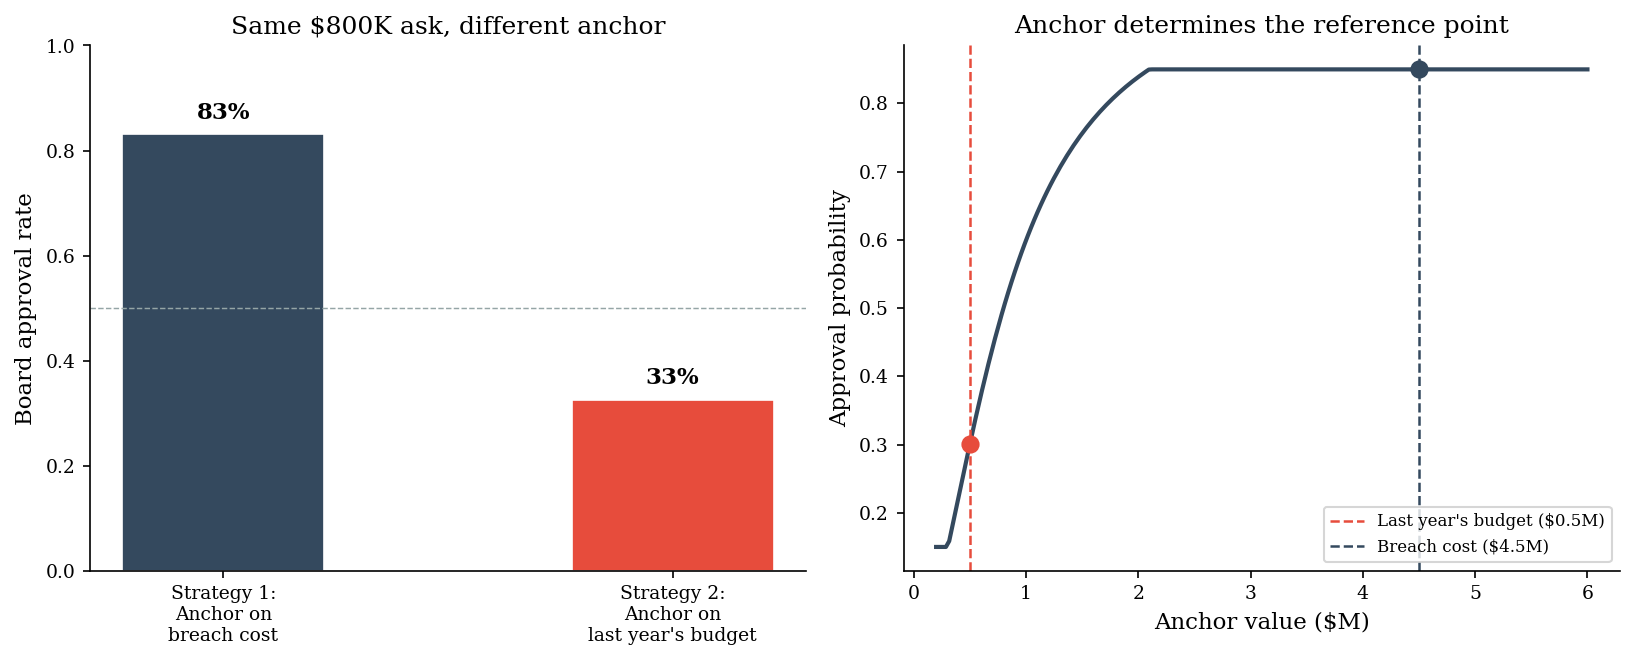

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left panel: the two strategies side by side
ax = axes[0]
strategies = ["Strategy 1:\nAnchor on\nbreach cost", "Strategy 2:\nAnchor on\nlast year's budget"]
approvals = [approval_1, approval_2]
colors_strat = [DARK_BG, ACCENT]
bars = ax.bar(strategies, approvals, color=colors_strat, edgecolor="white",
              linewidth=0.8, width=0.45)
for bar, rate in zip(bars, approvals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{rate:.0%}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Board approval rate")
ax.set_title("Same $800K ask, different anchor")
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color=LIGHT_GRAY, linestyle="--", linewidth=0.7)

# Right panel: anchor-to-ask ratio across a range
ax = axes[1]
anchor_range = np.linspace(200_000, 6_000_000, 200)
ratio_range = anchor_range / budget_ask
log_ratio_range = np.log(ratio_range)
prob_range = 1.0 / (1.0 + np.exp(-1.8 * log_ratio_range))
prob_range = np.clip(prob_range, 0.15, 0.85)

ax.plot(anchor_range / 1e6, prob_range, color=DARK_BG, linewidth=2)
ax.axvline(anchor_last_year / 1e6, color=ACCENT, linestyle="--", linewidth=1.2,
           label=f"Last year's budget (${anchor_last_year/1e6:.1f}M)")
ax.axvline(anchor_breach / 1e6, color=DARK_BG, linestyle="--", linewidth=1.2,
           label=f"Breach cost (${anchor_breach/1e6:.1f}M)")
ax.scatter([anchor_last_year / 1e6], [prob_2], color=ACCENT, s=60, zorder=5)
ax.scatter([anchor_breach / 1e6], [prob_1], color=DARK_BG, s=60, zorder=5)
ax.set_xlabel("Anchor value ($M)")
ax.set_ylabel("Approval probability")
ax.set_title("Anchor determines the reference point")
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

The anchor sets the negotiation range before the conversation begins. A
CISO who opens with the breach cost is not being manipulative — they are
providing the relevant reference point. A CFO who opens with last year's
budget is also providing a reference point. The question is which anchor
produces better decisions, not which is more "neutral" — there is no neutral.

## 5. Constructive Risk Communication

If framing is inescapable, the ethical response is to choose frames
deliberately, transparently, and in service of better decisions. The same
underlying Monte Carlo output can be communicated three ways, each suited to
a different audience:

- **(a) Quantile table** — dry but precise, suited for risk analysts
- **(b) Loss exceedance curve** — visual and intuitive for technical audiences
- **(c) Natural frequency statement** — "There is a 1-in-10 chance we lose more than \$X" — accessible to executives

All three come from the same simulation. The communicator chooses the frame.

In [10]:
# Simulate aggregate losses for a realistic cyber risk scenario
sev_comm = make_lognormal_severity(meanlog=12.5, sdlog=1.2)
losses_comm = simulate_aggregate_losses(10_000, lam=2.0, severity_sampler=sev_comm, rng=make_rng(77))

# Quantiles for the table
quantiles = [0.50, 0.75, 0.90, 0.95, 0.99]
quantile_values = np.quantile(losses_comm, quantiles)

var_95, es_95 = var_es(losses_comm, alpha=0.95)

print("=" * 50)
print("(a) Annual Loss Quantile Table")
print("=" * 50)
for q, v in zip(quantiles, quantile_values):
    print(f"  P{int(q*100):>2d}:  ${v:>12,.0f}")
print(f"\n  VaR(95%): ${var_95:>10,.0f}")
print(f"  ES(95%):  ${es_95:>10,.0f}")
print("\n")

# Natural frequency statements
p90_val = np.quantile(losses_comm, 0.90)
p95_val = np.quantile(losses_comm, 0.95)
p99_val = np.quantile(losses_comm, 0.99)

print("(c) Natural Frequency Statements")
print("=" * 50)
print(f"  There is a 1-in-10 chance we lose more than ${p90_val:,.0f} this year.")
print(f"  There is a 1-in-20 chance we lose more than ${p95_val:,.0f} this year.")
print(f"  There is a 1-in-100 chance we lose more than ${p99_val:,.0f} this year.")

(a) Annual Loss Quantile Table
  P50:  $     601,597
  P75:  $   1,433,188
  P90:  $   2,654,503
  P95:  $   3,781,680
  P99:  $   7,366,278

  VaR(95%): $ 3,781,639
  ES(95%):  $ 6,242,168


(c) Natural Frequency Statements
  There is a 1-in-10 chance we lose more than $2,654,503 this year.
  There is a 1-in-20 chance we lose more than $3,781,680 this year.
  There is a 1-in-100 chance we lose more than $7,366,278 this year.


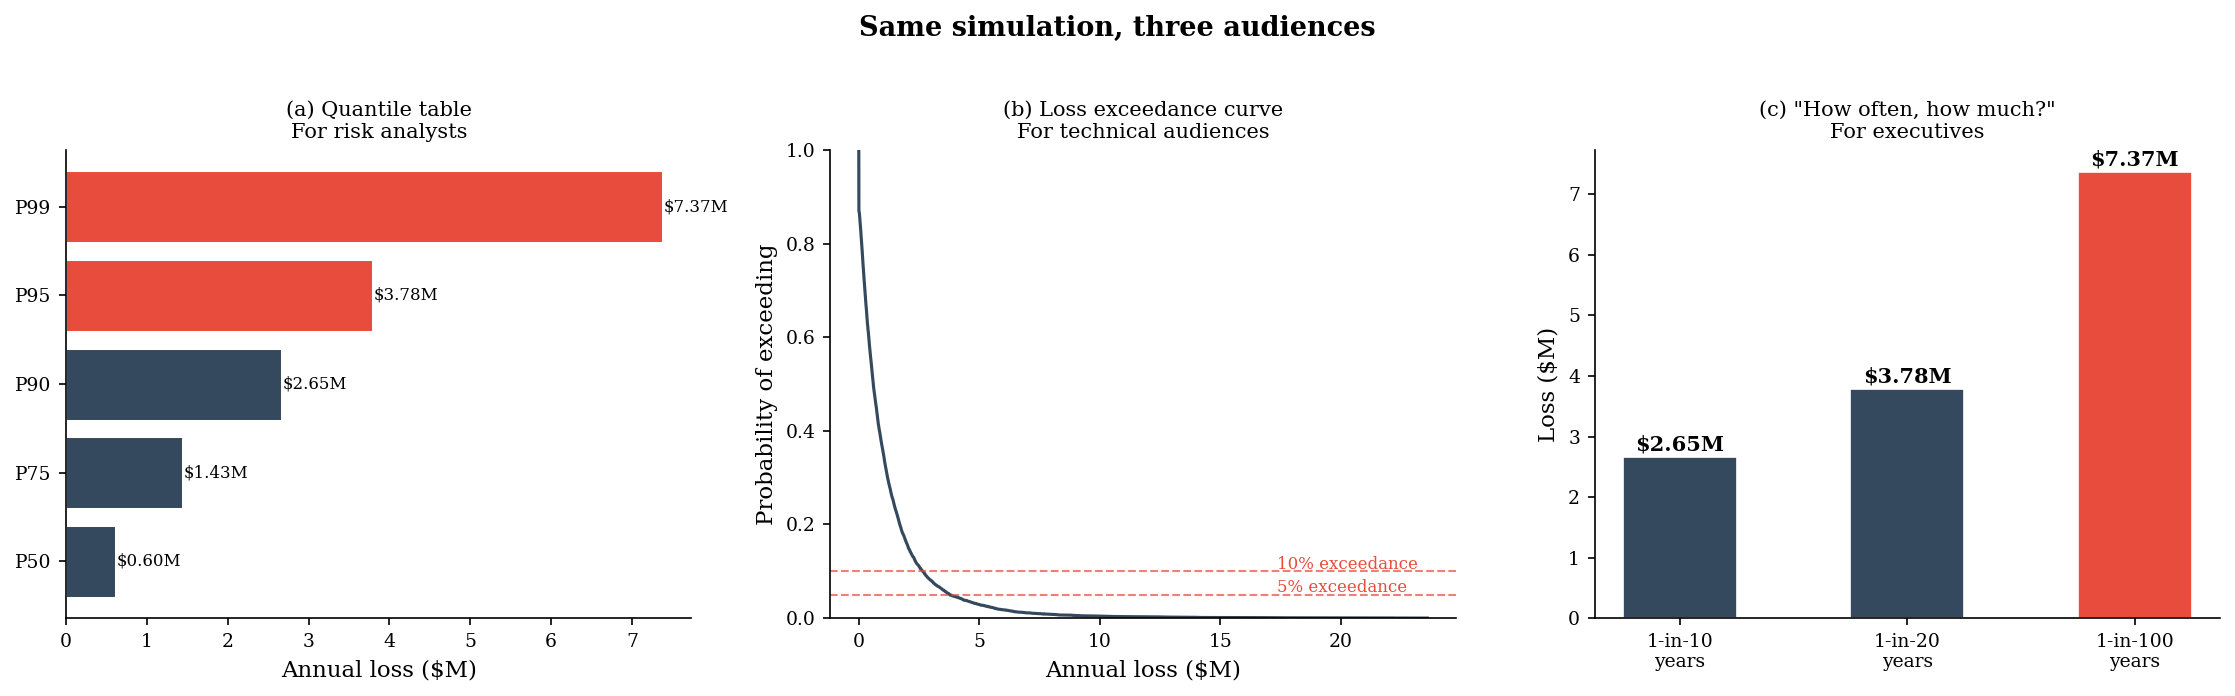

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Quantile table as a styled bar chart
ax = axes[0]
q_labels = [f"P{int(q*100)}" for q in quantiles]
colors_q = [DARK_BG if q < 0.95 else ACCENT for q in quantiles]
bars = ax.barh(q_labels, quantile_values / 1e6, color=colors_q,
               edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, quantile_values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f"${val/1e6:.2f}M", va="center", fontsize=8)
ax.set_xlabel("Annual loss ($M)")
ax.set_title("(a) Quantile table\nFor risk analysts", fontsize=10)

# (b) Loss exceedance curve
ax = axes[1]
sorted_losses = np.sort(losses_comm)
exceedance_prob = 1.0 - np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)
ax.plot(sorted_losses / 1e6, exceedance_prob, color=DARK_BG, linewidth=1.5)
ax.axhline(0.10, color=ACCENT, linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(0.05, color=ACCENT, linestyle="--", linewidth=1, alpha=0.7)
ax.text(ax.get_xlim()[1] * 0.7, 0.105, "10% exceedance", fontsize=8, color=ACCENT)
ax.text(ax.get_xlim()[1] * 0.7, 0.055, "5% exceedance", fontsize=8, color=ACCENT)
ax.set_xlabel("Annual loss ($M)")
ax.set_ylabel("Probability of exceeding")
ax.set_title("(b) Loss exceedance curve\nFor technical audiences", fontsize=10)
ax.set_ylim(0, 1.0)

# (c) Natural frequency statements as annotated visual
ax = axes[2]
freq_labels = ["1-in-10\nyears", "1-in-20\nyears", "1-in-100\nyears"]
freq_values = [p90_val / 1e6, p95_val / 1e6, p99_val / 1e6]
colors_freq = [DARK_BG, DARK_BG, ACCENT]
bars = ax.bar(freq_labels, freq_values, color=colors_freq, edgecolor="white",
              linewidth=0.8, width=0.5)
for bar, val in zip(bars, freq_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"${val:.2f}M", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("Loss ($M)")
ax.set_title('(c) "How often, how much?"\nFor executives', fontsize=10)

fig.suptitle("Same simulation, three audiences", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

All three panels present the same Monte Carlo output. The quantile table is
precise but opaque to a non-technical board. The exceedance curve is visual but
requires statistical literacy. The natural frequency statement — "a 1-in-10
chance of losing more than $X" — is immediately accessible. None of these is
more "correct" than the others. The communicator's job is to match the frame to
the audience.

## 6. Pitfalls

**Gain/loss framing reverses preferences with no new information.**
The same expected value produces different approval rates depending on whether
the investment is presented as preventing loss or securing gain. This is not
a failure of rationality to be fixed — it is a stable feature of human
decision-making that must be anticipated.

**Denominators are chosen strategically.**
Absolute numbers alarm; rates reassure. A vulnerability count of 10,000 triggers
a different response than "0.3% of assets." Both are true. Neither is complete.
Anyone presenting one without the other has made a framing choice.

**Risk matrices impose false precision on different distributions.**
A single score (likelihood x impact) collapses the entire loss distribution
into one number. Two risks with the same score can have radically different
tail behavior. The matrix makes them look interchangeable. They are not.

**Anchors set the negotiation range before the conversation begins.**
The first number in a budget presentation is not context — it is the reference
point against which everything else is judged. Choosing the anchor is choosing
the outcome.

**There is no neutral frame.**
Every table, chart, and sentence in a risk report is a framing decision. The
choice is not between "framing" and "not framing" — it is between framing
deliberately and framing accidentally.

> "He uses statistics as a drunken man uses lamp posts — for support rather
> than for illumination." — attributed to Andrew Lang